# Exploratory Data Analysis & Business Intelligence
## Superstore Sales Dataset

This project performs exploratory data analysis (EDA) and SQL-based business analysis
to uncover trends, patterns, and profitability insights.

Tools Used:
- Python (Pandas, Matplotlib)
- SQLite (SQL Queries)
- PowerPoint (Static Dashboard)


## 1. Data Loading

Loading the cleaned dataset for analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv("../data/cleaned_superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Delivery Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,7,0.1125


## 2. Descriptive Statistics & Univariate Analysis

Summary statistics were calculated to understand numerical distributions
and general dataset characteristics.

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Delivery Days,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,3.958175,0.120314
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.747567,0.466754
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,0.000000,-2.750000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,3.000000,0.075000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,4.000000,0.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,5.000000,0.362500
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,7.000000,0.500000


Observations:

Average sales ≈ 229

Profit ranges from negative to positive

Discount average ≈ 0.15

Data is highly skewed (large max sales)

In [5]:
df['Category'].value_counts()
df['Region'].value_counts()
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

### Key Performance Indicators (KPIs)

In [6]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_discount = df['Discount'].mean()

total_sales, total_profit, total_orders, avg_discount

(np.float64(2297200.8603000003),
 np.float64(286397.0217),
 5009,
 np.float64(0.15620272163297977))

### Sales Distribution

The histogram shows that most transactions are low-value,
with a few high-value outliers.

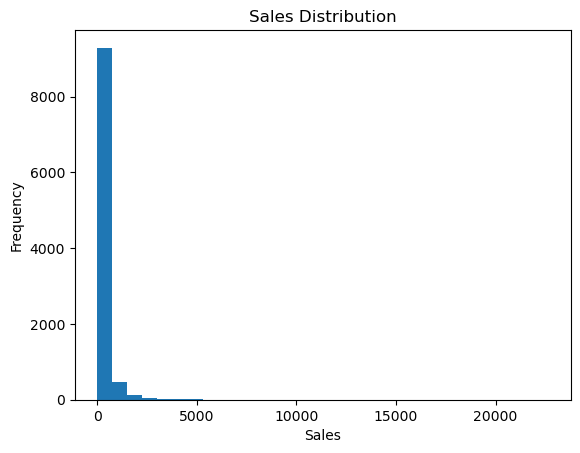

In [7]:
plt.figure()
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Category Distribution

This chart shows the count of transactions across categories.

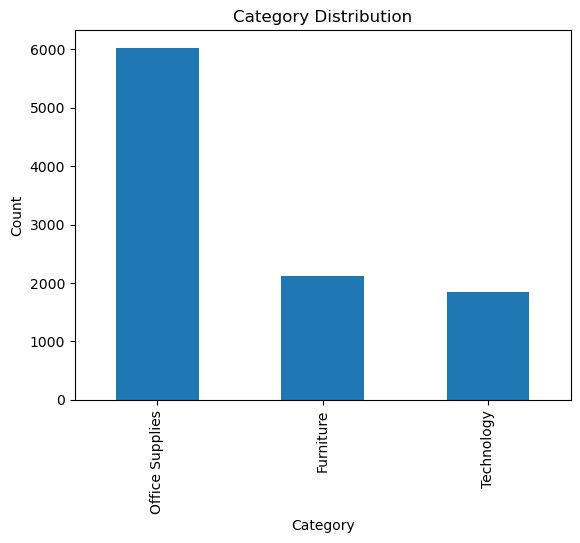

In [8]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.ylabel("Count")
plt.show()

### Monthly Sales Trend Analysis

In [ ]:
monthly_sales = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()

plt.figure()
plt.plot(monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month Index")
plt.ylabel("Sales")
plt.show()

## 3. SQL Business Analysis

Business questions were answered using SQL queries
executed through SQLite.

In [ ]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

In [ ]:
query1 = """
SELECT "Product Name",
       SUM(Sales) AS Total_Sales
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 5;
"""

pd.read_sql(query1, conn)

In [ ]:
query2 = """
SELECT "Order Year",
       "Order Month",
       SUM(Sales) AS Monthly_Sales
FROM sales
GROUP BY "Order Year", "Order Month"
ORDER BY "Order Year", "Order Month";
"""

pd.read_sql(query2, conn)

In [ ]:
query3 = """
SELECT Category,
       SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query3, conn)

In [ ]:
query4 = """
SELECT Region,
       SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query4, conn)

In [ ]:
query5 = """
SELECT Segment,
       AVG(Discount) AS Avg_Discount
FROM sales
GROUP BY Segment;
"""
pd.read_sql(query5, conn)

## 4. Multivariate Analysis

A scatter plot was created to examine the relationship
between Sales and Profit.

### Correlation Matrix

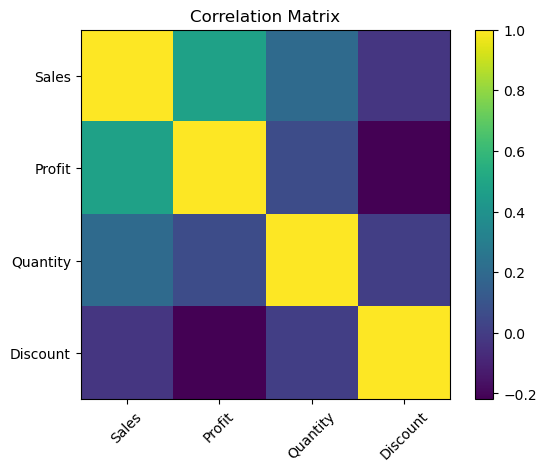

In [9]:
corr = df[['Sales','Profit','Quantity','Discount']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
plt.figure()
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit Relationship")
plt.show()

### Discount vs Profit

In [ ]:
plt.figure()
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()


### Quantity vs Sales

In [ ]:
plt.figure()
plt.scatter(df['Quantity'], df['Sales'])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

In [ ]:
df[['Sales','Profit','Quantity','Discount']].corr()

## 5. Key Business Insights

- Technology is the most profitable category.
- Sales peak during Q4, indicating seasonal demand.
- Some high-revenue transactions generate negative profit due to heavy discounting.
- Discount strategy is consistent across customer segments.
- West region contributes highest overall profit.

## 6. Dashboard Metrics Used

The following KPIs were used to build the static dashboard:

- Total Sales
- Total Profit
- Total Orders
- Average Discount
- Monthly Sales Trend
- Profit by Region
- Sales by Category